In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391150 entries, 0 to 391149
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    391150 non-null  int64         
 1   StockCode    391150 non-null  object        
 2   Description  391150 non-null  object        
 3   Quantity     391150 non-null  int64         
 4   InvoiceDate  391150 non-null  datetime64[ns]
 5   UnitPrice    391150 non-null  float64       
 6   CustomerID   391150 non-null  int64         
 7   Country      391150 non-null  object        
 8   Revenue      391150 non-null  float64       
 9   YearMonth    391150 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 29.8+ MB


## Define Future Prediction Window

To simulate real-world prediction, we split the dataset into:

**Historical Data**  
→ Used to calculate RFM features

**Future Data**  
→ Used to calculate customer revenue in the next two months.

*The model will learn patterns from historical behavior and predict future revenue.*

In [4]:
cutoff_date = df['InvoiceDate'].max() - pd.DateOffset(months=2)

In [5]:
historical_df = df[df['InvoiceDate'] < cutoff_date]
future_df = df[df['InvoiceDate'] >= cutoff_date]

## Feature Engineering

**Recency**
-> The number of days since the customer's last purchase. Customers who purchased recently are more likely to buy again.

**Frequency**
-> The number of transactions made by the customer. Customers who purchase frequently tend to be more engaged with the business.

**Monetary**
-> The total amount of money the customer has spent. Customers who spend more are typically more valuable to the business.

In [6]:
snapshot_date = historical_df['InvoiceDate'].max() + timedelta(days=1)

rfm = historical_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

## Future Revenue Target

To predict customer lifetime value, we need a target variable representing future customer spending.

Instead of using a calculated CLV formula, we compute the actual revenue generated by each customer in the next two months.

This future revenue acts as the prediction target for our machine learning models.

Customers who do not make any purchases during the prediction window are assigned a value of zero.

In [7]:
future_revenue = future_df.groupby('CustomerID')['Revenue'].sum().reset_index()
future_revenue.columns = ['CustomerID', 'FutureRevenue']

In [8]:
future_revenue.head()

,CustomerID,FutureRevenue
0,12347,1519.14
1,12349,1457.55
2,12352,231.73
3,12356,58.35
4,12357,6207.67


## Merge Features and Target

After calculating RFM features and future revenue, we combine them into a single dataset.

Each row now represents one customer and includes:

• Behavioral features (Recency, Frequency, Monetary)
• Target variable (FutureRevenue)

Customers who did not make purchases during the prediction window will have missing values, which are replaced with zero.

In [9]:
rfm = rfm.merge(future_revenue, on='CustomerID', how='left')
rfm['FutureRevenue'] = rfm['FutureRevenue'].fillna(0)

In [10]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,FutureRevenue
0,12346,265,1,77183.60,0.00
1,12347,69,5,2790.86,1519.14
2,12348,14,4,1437.24,0.00
3,12350,249,1,294.40,0.00
4,12352,11,6,1154.01,231.73


## Handling Skewed Revenue Distribution

Customer revenue data typically has a highly skewed distribution.

This happens because:
• Many customers spend small amounts
• A few customers spend very large amounts

Such extreme values can negatively impact machine learning models.

To stabilize the training process, we apply a logarithmic transformation to the target variable using the log1p function.

In [11]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = np.log1p(rfm['FutureRevenue'])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
numeric_features = ['Recency', 'Frequency', 'Monetary']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features)
    ]
)

## Model Training and Comparison

We train four regression models:

• Linear Regression

• Random Forest

• Gradient Boosting

• XGBoost

We compare their performance using:

RMSE (Root Mean Squared Error)  
R² Score (Coefficient of Determination)

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror')
}

## Train Model

In [15]:
results = []

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)

    y_pred_log = pipeline.predict(X_test)

    y_pred = np.expm1(y_pred_log)
    y_test_original = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
    r2 = r2_score(y_test_original, y_pred)

    results.append((name, rmse, r2))

In [16]:
results_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'R2'])
results_df.sort_values(by='R2', ascending=False)

,Model,RMSE,R2
1,Random Forest,1.702773e+03,6.768924e-01
3,XGBoost,1.958903e+03,5.723788e-01
2,Gradient Boosting,2.458178e+03,3.266203e-01
0,Linear Regression,1.915462e+11,-4.088656e+15


In [23]:
#Save model results
results_df.to_csv("../results/model_comparison_results.csv", index=False)
results_df

,Model,RMSE,R2
0,Linear Regression,1.915462e+11,-4.088656e+15
1,Random Forest,1.702773e+03,6.768924e-01
2,Gradient Boosting,2.458178e+03,3.266203e-01
3,XGBoost,1.958903e+03,5.723788e-01


In [17]:
best_model_name = results_df.sort_values(by='R2', ascending=False).iloc[0]['Model']
print("Best Model:", best_model_name)

Best Model: Random Forest


## Feature importance with pipeline

In [18]:
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models[best_model_name])
])

best_pipeline.fit(X_train, y_train)

model = best_pipeline.named_steps['model']

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    
elif hasattr(model, "coef_"):
    importances = model.coef_
    
else:
    print("Model does not support importance extraction")
    importances = None


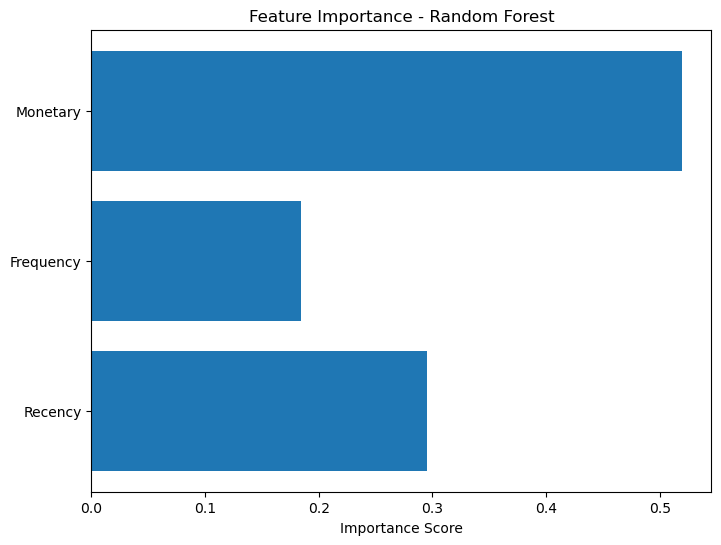

In [21]:
if importances is not None:
    plt.figure(figsize=(8,6))
    features = numeric_features
    plt.barh(features, importances)
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance Score")
    #Saving plot in results folder
    plt.savefig("../results/feature_importance.png", bbox_inches="tight")
    plt.show()

## Visualizing the future revenue distribution

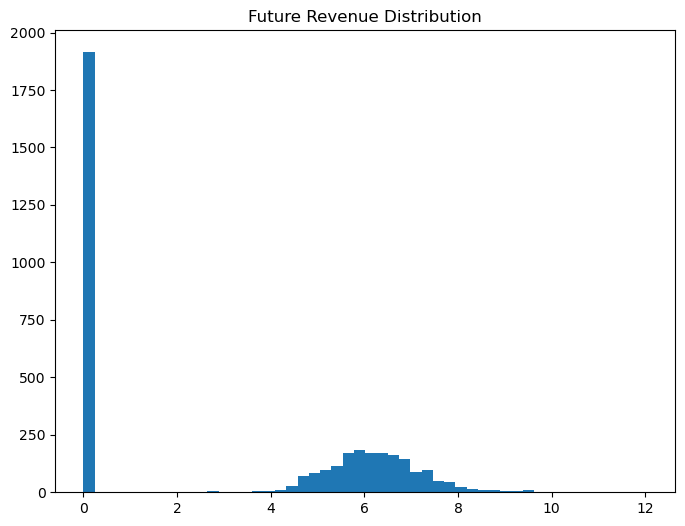

In [22]:
plt.figure(figsize=(8,6))
plt.hist(y, bins=50)
plt.title("Future Revenue Distribution")
#Saving plot in results folder
plt.savefig("../results/future_revenue_distribution.png", bbox_inches="tight")
plt.show()

## Key Findings and Interpretation

Based on the feature importance analysis from the trained machine learning model, the three RFM features contribute differently to predicting future customer revenue. The importance ranking observed in the model is:

**Monetary > Recency > Frequency**

Monetary value emerged as the most influential feature in predicting future customer spending. This indicates that customers who have historically spent higher amounts tend to generate higher revenue in the future as well. In other words, past spending behavior is the strongest signal for identifying high-value customers.

Recency was the second most important factor. Customers who have made purchases more recently are more likely to return and generate additional revenue. This suggests that customer engagement and recent activity play an important role in predicting near-term customer value.

Frequency had the lowest importance among the three features, although it still contributes to the prediction. While customers who purchase frequently are valuable, the total amount they spend and how recently they purchased appear to be stronger indicators of future revenue in this dataset.

Overall, the model highlights that historical spending behavior combined with recent customer activity provides the most useful signals for predicting short-term customer lifetime value.

From a business perspective, these insights can help companies prioritize marketing efforts toward customers who have spent significant amounts and have interacted with the business recently, as they are more likely to generate higher revenue in the near future.

## END